# 6: Computer Vision

This chapter explores causal inference applications in computer vision (CV), which uses images or video as inputs.
CV is widely adopted across sectors like tech, healthcare, manufacturing and defence.
Recent advances apply causal methods to address key CV challenges, covering common tasks, techniques and how causality enhances solutions.

#### Prerequisite Knowledge

Minimal prior knowledge is needed.
Those with computer vision experience will benefit more, though key concepts are introduced as required.

Readers wanting to learn computer vision holistically should explore these resources:

* Howard and Gugger’s 2020 book *Fast AI* covers computer vision in two chapters.
* Andrew Ng's Coursera course on Convolutional Neural Networks and Computer Vision.

## 6.1: The Current State of Computer Vision

Computer vision advanced significantly after Yann LeCun’s CNN work (1998), accelerating from AlexNet’s 2012 ImageNet breakthrough using deep learning, boosted by increased computing power and big data.

Computer vision includes tasks like image classification, object detection, and image generation.
Applications range from medical imaging and factory quality control to self-driving car systems.
Deep learning dominates, with convolutional networks and Transformers commonly used across different tasks.

Common CV project issues mirror broader ML challenges, particularly poor robustness when transferring to new datasets.
This stems from data-hungry models seizing spurious correlations (e.g., background textures), worsened by deep learning’s inherent uninterpretability.
While tools like gradient-based saliency maps offer limited insight, they fail to reliably explain model decisions or identify learning errors.

## 6.2: Causal Methods in Computer Vision

Causal inference addresses spurious correlations in computer vision (CV), a key strength for the field.
A *Nature* paper (Castro et al., 2020) highlights its importance in clinical settings, stressing that mismatches between training data and real-world deployment (causing severe performance issues) can be avoided using causal reasoning.
This approach also enhances model performance and robustness in new environments.

This section outlines causal methods in computer vision subfields: object recognition, segmentation, few-shot learning, vision-language tasks, and robustness, followed by a case study.

### 6.2.1: Image Classification

Image classification, a core computer vision task, predicts an image's category from predefined classes.
ImageNet, a key benchmark dataset, contains over 14 million labelled images across thousands of hierarchical categories (Deng et al., 2009; [Figure 6.1](#fig-dog)).

<center>
  <img
    src="images/image_net_example.jpg"
    alt="An example from the ImageNet training set, labeled “Staffordshire bull terrier”"
    width="400"/>
  <a id="fig-dog"></a>
  <h6>Figure 6.1: An example from the ImageNet training set, labeled “Staffordshire bull terrier”</h6>
</center>

A puppy image labelled "Staffordshire bull terrier" illustrates common computer vision pitfalls.
When training a model to distinguish this breed from others (e.g., Boston terriers), the ideal focus is on key features like coat patterns and muzzle shape.
However, models often learn spurious correlations (such as irrelevant traits) to minimise training error, rather than genuine breed differences.

A watermark (breeder's URL) in [Figure 6.1](#fig-dog) risks training models to recognise the URL instead of key features like ear shape.
This causes failure on real-world images, showing how CV models learn unwanted patterns.
Such spurious correlations are addressed in Section 6.2.5 on robustness.

Confounding factors (e.g., human hands holding a dog in training images) can cause models to learn irrelevant features instead of the target subject.
Manually labelling such confounders is impractical.
The Causal Attention Module (CaaM) addresses this by unsupervisedly modelling confounders within standard attention mechanisms (e.g., ViT, CNNs), enabling intervention without manual annotation.
CaaM improves both in-domain and out-of-domain performance over standard attention and non-attention models (Wang et al., 2021).

### 6.2.2: Few-Shot Learning

Transfer learning accelerates deep learning model development by first pre-training on large datasets (e.g., image reconstruction) then fine-tuning for specific tasks.
This reduces the need for extensive labelled data.
Key pre-trained computer vision models include ResNet and Vision Transformer for classification, and YOLO for object detection.

Few-shot learning (FSL) is a transfer learning approach where models generalise to new tasks using minimal labelled data.
It tests how well pre-trained models adapt to unfamiliar domains with few examples, demonstrating that deep learning can achieve meaningful performance from just a handful of task-specific observations.

Negative transfer occurs when pretrained knowledge harms performance in few-shot fine-tuning.
A causal perspective (Yue et al. 2020, NeurIPS) explains this: pretrained knowledge $D$ feeds into feature representations $X$, transformed in a low-rank manifold $C$, yielding task outputs $Y$, as shown in [Figure 6.2](#fig-ifsl-graph).

<center>
  <img
    src="images/interventional_few_shot.png"
    alt="Causal graph for interventional few-shot learning"
    width="400"/>
  <a id="fig-ifsl-graph"></a>
  <h6>Figure 6.2: Causal graph for interventional few-shot learning</h6>
</center>

Pre-trained model biases confound few-shot learning (FSL) performance.
For example, a model trained only on indoor rug scenes might wrongly associate dogs with such settings, lacking sufficient FSL examples to correct this bias.

The authors propose an intervention to eliminate confounder effects in few-shot learning.
In standard (many-shot) transfer, a model adapts fully to the task (effectively modelling $P(Y|do(X))$).
However, in few-shot learning, a confounder *D* strongly influences the output *Y*, disrupting this.
They address this by intervening on $D \rightarrow X$ using backdoor adjustment to directly model $P(Y|do(X))$.
This is achieved through two methods:
- A feature-level adjustment using pretrained layer outputs.
- A class-level adjustment for classification-based pretraining tasks (e.g., ImageNet).

IFSL enhances few-shot learning (FSL) performance across diverse tasks and computer vision models.
It delivers greater gains in 1-shot than 5-shot settings, with larger improvements when the FSL domain differs significantly from the pretraining domain.
Existing FSL boosting methods, such as data augmentation, approximate this intervention.

### 6.2.3: Weakly Supervised Semantic Segmentation

Semantic segmentation assigns pixel-level masks to objects in images, grouping similar items (e.g., all people or dogs) into distinct classes.
It is used in medical imaging to differentiate tissues and in autonomous driving to identify pedestrians, vehicles, and road signs.

Semantic segmentation requires costly pixel-level labelling, far more labour-intensive than tasks like image classification.
Weakly supervised semantic segmentation (WSSS) reduces this burden by using image-level labels to train a classifier, which then generates 'pseudo masks' for segmentation (Ahn & Kwak, 2018).
This approach leverages one model’s output as training data for another, significantly cutting labelling effort and enabling faster data collection.

Zhang et al. (2020) introduce a causal method for weakly supervised semantic segmentation (WSSS) using backdoor adjustment to reduce spurious correlations from class co-occurrence and incomplete labels.
Their approach, Context Adjustment (CONTA), intervenes on class co-occurrence.
The causal graph ([Figure 6.3](#fig-conta-graph)) defines:
- $X$: Image observation
- $Y$: Class labels
- $C$: Context prior (data-generating process)
- $M$: Image-specific context (for $X$)

<center>
  <img
    src="images/conta_graph.png"
    alt="Causal graph for Context Adjustment in weakly supervised semantic segmentation"
    width="400"/>
  <a id="fig-conta-graph"></a>
  <h6>Figure 6.3: Causal graph for Context Adjustment in weakly supervised semantic segmentation</h6>
</center>

The context $C$ influences class labels $Y$ only via pathways through observations $X$ and mediators $M$.
CONTA trains classifiers to learn $P(Y \mid \text{do}(X))$—not standard $P(Y \mid X)$, using class-wise average pseudo masks for intervention during training.
This creates an EM-like iterative algorithm.

1. Train multilabel image classifier using custom loss with class-averaged mask similarity.
2. Generate pseudo-masks from classifier attribution maps
3. Train the segmentation model on pseudo-masks
4. Update class-averaged masks with segmentation model output

After iterations, the model achieves cleaner entity boundaries and better handles complex images.
The framework is architecture-agnostic, compatible with any segmentation method and incorporates causal techniques. Code: https://github.com/dongzhang89/CONTA.

**Additional work in WSSS**

A CVPR 2022 paper proposes a WSSS medical image segmentation method building on CONTA’s pseudo-masking approach using classifier saliency maps.
Chen et al. enhance this by adding anatomical structure maps, improving performance over prior state-of-the-art methods on medical segmentation tasks. [Chen et al. 2022]

### 6.2.4: Vision-Language Tasks

Vision-language models are growing in popularity, with breakthroughs like DALL-E generating images from text prompts.
Key tasks include image captioning, visual question answering, and reasoning.
Techniques such as visual attention and Transformer models (e.g., BEiT) show strong results.
This section covers three causal inference applications to enhance model performance and reliability.

**Visual Commonsense R-CNN**

Wang et al. (2020) propose VC R-CNN, integrating region-based CNN with a visual commonsense module.
It learns robust features unsupervised by controlling image confounders via backdoor adjustment.
The model uses class-specific region-of-interest feature dictionaries with scaled dot-product attention.
It boosts performance in vision-language tasks, with larger gains in captioning than VQA. Code: http://github.com/Wangt-CN/VC-R-CNN.

**Causal Attention**

Attention in vision-language tasks strengthens image-text relationships but can learn spurious correlations during training, harming real-world performance.
Yang et al. (2021) propose CATT, a causal attention module that reduces confounder effects using front-door adjustment.
Unlike methods needing explicit confounder data (e.g., VC R-CNN), CATT integrates directly into vision Transformers to intervene causally.

CATT uses CS-Sampling—additional stratified sampling from other data points—to produce a deconfounded predictor.

> CS-Sampling breaks spurious correlations by mixing object regions across samples. For example, instead of always seeing "man-with-snowboard," a model sees "man" with unrelated objects (like bike or mirror).
> This forces the model to focus on the person region to infer gender correctly.

CATT uses front-door adjustment to create unbiased VQA predictors.
It projects training regions into embeddings, employing two sampling methods:
- **IS-Sampling**: Uses only the input image.
- **CS-Sampling**: Uses related training images as attention keys/values.
This works for both self-attention (image regions) and top-down attention (image to text), stacking in Transformers.
- It improves standard VQA performance and boosts smaller models.

**Counterfactual Visual Question Answering**

Unlike CATT and VC R-CNN, Niu et al. (2021) address language bias in VQA, where 90% of 'do you see a...' questions in VQA v1.0 are answered 'yes' correctly.
Their counterfactual method removes bias by simulating scenarios without visual evidence.

Niu et al. (2021) uses counterfactual methods to study language bias in VQA, separating direct and indirect effects of three factors on answers.

1. The input image in isolation, $V$
2. How language bias works
3. Multimodal reasoning is VQA's core objective.

In VQA, the query $Q$, key $K$, and value $V$ align with attention mechanisms.
Direct $Q \rightarrow A$ influence is undesirable: answers must not depend solely on questions.
Instead, models should link questions to images for answers.
Authors measure direct vs. indirect $Q$ effects, selecting answers with the strongest indirect effects, avoiding simple posterior probability sampling.

### 6.2.5: Robustness and Transfer

Previous sections covered causal methods for CV subdomains.
This section examines model robustness and transferability.

Most CV robustness research focuses on image classification, with causal approaches applied there.
Key methods include removing spurious features (e.g., texture) and causal generalisation evaluation.
The field will continue evolving.

**Counterfactual Data Augmentation for Robust Image Classifiers**

Complex ML models often learn misleading patterns, not just in computer vision.
Sauer and Geiger (2021) propose Counterfactual Generative Networks (CGN), a GAN-based method that disentangles image elements (shape, texture, background).
Trained using only class labels and pretrained models, CGN generates images with specified attributes.
For example, it can create an image with an "ostrich" shape, "strawberry" texture, and "diving" background ([Figure 6.4](#fig-cgn-example)).

<center>
  <img
    src="images/cgn_example.png"
    alt="An image generated by Counterfactual Generative Network"
    width="400"/>
  <a id="fig-cgn-example"></a>
  <h6>Figure 6.4: An image generated by Counterfactual Generative Network</h6>
</center>

Researchers used generative models to create synthetic training data (e.g., modified MNIST digits, animals on varied backgrounds).
This improved model generalisation, suggesting future work in causal robustness and counterfactual modelling.

**Causal Inference for Model Generalization**

Robustness also focuses on model transferability, involving two key goals:

1. Model generalization,
2. Understanding model transfer failures: when and how they occur.

Computer vision models typically perform well on similar data but fail when faced with different distributions.
For example, a model trained on Staffordshire bull terrier puppies ([Figure 6.1](#fig-dog)) may not recognise adult dogs in new environments.

Transportability describes whether model knowledge transfers between environments. 
Its absence causes generalisation failure in image classification, as Mao et al. (2022) demonstrated using causal models to show the image-label relationship differs between training and new settings.

Transportability issues occur when in-distribution conditional probabilities $P(Y|X)$ differ from out-of-distribution cases. 
The authors decompose $P(Y|X)$ into two components per setting.

1. **Causal effect:** an invariant feature (e.g., dog muzzle shape, fur colour/length).
2. **Spurious effect:** inconsistent context features causing generalisation failure (e.g. backgrounds/lighting).

The authors demonstrate that causal effects $P(Y|do(X))$ for image classification can be estimated without extra data. 
This is achieved by embedding causal structure into deep neural network representations.

* Images comprise causal and spurious features.
* Neural models can learn representations of causal factors.
* The classifier mimics the true labeler by combining causal factors from an in-distribution image $x$ with spurious factors from an out-of-distribution image $x'$.

For settings meeting the assumptions, the framework identifies causal effects during training and evaluation using VAEs or pretrained encoders to generate image representations.
Within-class sampling builds robust features for better transfer, assessed via causal effect estimation.

Mao et al. (2022) reduce spurious correlations in image classification, significantly improving generalisation in adversarial domain generalisation tasks.
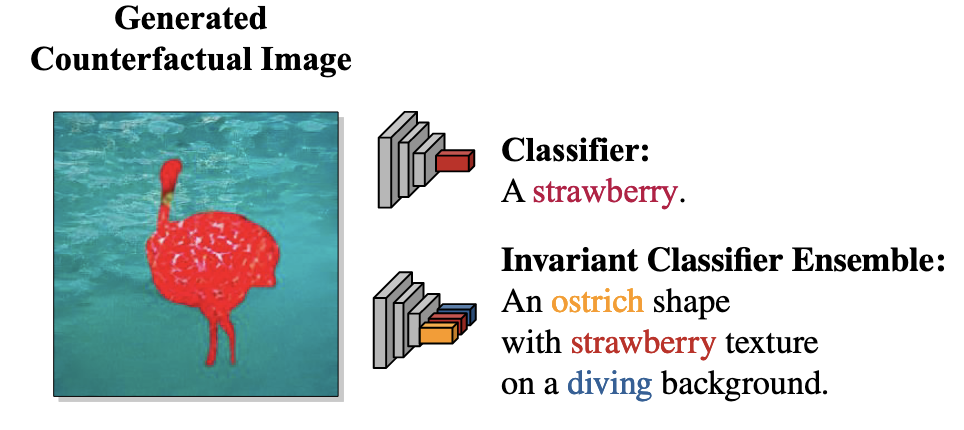

## 6.3: Case Study

Available on [Google Colab](https://colab.research.google.com/drive/1nOO77UGrcE9aUlaXwkEQB2QoPv8Y9v0l?usp=sharing) with a walkthrough.

This case study re-implements Mao et al. (2022) using Coloured MNIST (Arjovsky et al., 2020), a benchmark testing classifier robustness under adversarial colour shifts between training and test sets.

The Coloured MNIST dataset uses standard MNIST digits, colouring backgrounds by class for training images and randomly for test images, as shown in [Figure 6.5](#fig-mnist-train).

<center>
  <img
    src="images/color_mnist_example_training_0.png"
    alt="An image in the MNIST training set with two color shifts applied"
    width="400"/>
  <a id="fig-mnist-train"></a>
  <h6>Figure 6.5: An image in the MNIST training set with two color shifts applied</h6>
</center>

Two MNIST training examples show the digit '7' with different colourings: white on yellow and yellow on black. 
Both variants appear in the training set ([Figure 6.6](#fig-mnist-train-test)). 
A test image labelled '7' uses a distinct colour scheme not present in the training examples.

<center>
  <img
    src="images/color_mnist_train_vs_test.png"
    alt="Three images labeled "seven" in the Colored MNIST dataset"
    width="400"/>
  <a id="fig-mnist-train-test"></a>
  <h6>Figure 6.6: Three images labeled “seven” in the Colored MNIST dataset</h6>
</center>

Causal transportability methods typically use a VAE as an image encoder, though alternatives like ResNet are viable ([Figure 6.7](#fig-mnist-vae) shows a Coloured MNIST example).

<center>
  <img
    src="images/color_mnist_reconstruction.png"
    alt="An image from the training set (left) with its reconstructed autoencoder output (right)"
    width="400"/>
  <a id="fig-mnist-vae"></a>
  <h6>Figure 6.7: An image from the training set (left) with its reconstructed autoencoder output (right)</h6>
</center>

The autoencoder encodes input images.
The causal classifier uses similar labelled training fragments to learn relevant features from each batch.
However, it did not outperform a non-causal benchmark with a similar architecture, as shown in [Figure 6.8](#fig-mnist-perf) (Coloured MNIST results).

<center>
  <img
    src="images/color_mnist_performance.png"
    alt="Model performance on Colored MNIST"
    width="400"/>
  <a id="fig-mnist-perf"></a>
  <h6>Figure 6.8: Model performance on Colored MNIST</h6>
</center>

The causal classifier underperforms the non-causal benchmark on test data, possibly due to baseline differences, dataset modifications, or encoder design; CNN or attention-based encoders might improve results.

Causality in computer vision remains an active research area, offering potential gains in robustness.
Crucially, causal methods can be implemented similarly to standard deep learning code (e.g., PyTorch), making them accessible for wider adoption and further experimentation.

## 6.4: Conclusions

This chapter explains why computer vision practitioners should use causality.
Early results show promise, especially in image classification and vision-language tasks.

A case study on Coloured MNIST compared causal transportability with standard classification.
Though performance was similar, the causal method offers a streamlined PyTorch implementation for future work.
